Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Carregando as imagens de treino
Found 224 files belonging to 2 classes.
Carregando as imagens de teste
Found 56 files belonging to 2 classes.
Iniciando o treinamento
Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.8125 - loss: 0.3198 - val_accuracy: 1.0000 - val_loss: 0.0409
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 565ms/step - accuracy: 0.9821 - loss: 0.0574 - val_accuracy: 1.0000 - val_loss: 0.0263
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 959ms/step - accuracy: 0.9955 - loss: 0.0151 - val_accuracy: 1.0000 - val_loss: 0.0068
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 598ms/step - accuracy: 1.0000 - loss: 0.0100 - val_accuracy: 1.0000 - val_loss: 0.0048
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 597ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 1.0000 - val_loss: 0.0136
Gerando as métricas finais


1/2 ━━━━━━━━━━━━━━━━━━━━ 6s 7s/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step

--- CLASSIFICAÇÃO ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       1.00      1.00      1.00        28

    accuracy                           1.00        56
   macro avg       1.00      1.00      1.00        56
weighted avg       1.00      1.00      1.00        56



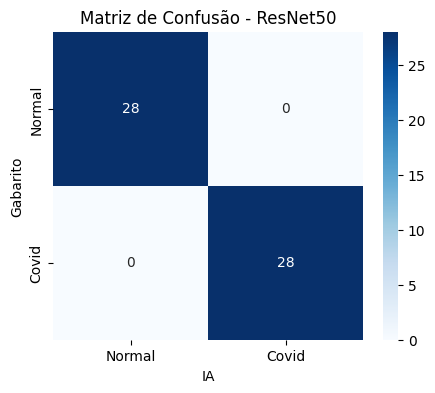

In [3]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from google.colab import drive


drive.mount('/content/drive')

caminho_treino = '/content/drive/MyDrive/Projeto_Covid19/covid19/train'
caminho_teste = '/content/drive/MyDrive/Projeto_Covid19/covid19/test'

print("Carregando as imagens de treino")
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    caminho_treino,
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)

print("Carregando as imagens de teste")
val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    caminho_teste,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)


base_model = ResNet50(input_shape=(224, 224, 3), include_top=False, weights='imagenet')


base_model.trainable = False


x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation='relu')(x)
predicoes = Dense(1, activation='sigmoid')(x)


modelo = Model(inputs=base_model.input, outputs=predicoes)

modelo.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


print("Iniciando o treinamento")
modelo.fit(train_dataset, epochs=5, validation_data=val_dataset)


print("Gerando as métricas finais")
y_true = np.concatenate([y for x, y in val_dataset], axis=0)
predicoes_prob = modelo.predict(val_dataset)
y_pred = np.where(predicoes_prob > 0.5, 1, 0)


print("\n--- CLASSIFICAÇÃO ---")
print(classification_report(y_true, y_pred))


cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Covid'], yticklabels=['Normal', 'Covid'])
plt.title('Matriz de Confusão - ResNet50')
plt.ylabel('Gabarito')
plt.xlabel('IA')
plt.show()